# Analytic calculations 

Via a hideous page of algebra and some possibly questionable continuity assumptions, applying Green's theorem to the sersic area integral gives this possible line integral:

$\oint x \arctan(\frac{y}{x}) e^{(x^2+y^2)^{\frac{1}{2n}}} dx + y \arctan(\frac{y}{x}) e^{(x^2+y^2)^{\frac{1}{2n}}} dy$

It's still not analytic but more straightforward to sample reasonably numerically and has better pre-computable factors, lets first check if it satisfies Green's Theorem for a Sersic area integrand:

In [1]:
import sympy
from sympy.printing.numpy import SciPyPrinter

In [2]:
dx, dy = sympy.symbols('dx, dy', real=True)
r,x,y,n = sympy.symbols('r,x,y,n', real=True, positive=True)

In [3]:
sersic = sympy.exp(-(sympy.sqrt(x**2 + y**2)**(1/n)))
sersic

exp(-(x**2 + y**2)**(1/(2*n)))

In [4]:
Fx = x*sympy.atan2(y, x)*sersic
Fy = y*sympy.atan2(y, x)*sersic

sympy.simplify(sympy.diff(Fy, x) - sympy.diff(Fx, y))

-exp(-(x**2 + y**2)**(1/(2*n)))

In [5]:
sympy.simplify(Fx*dx + Fy*dy)

(dx*x + dy*y)*exp(-(x**2 + y**2)**(1/(2*n)))*atan(y/x)

In [6]:
fFx = sympy.lambdify((x,y,n),Fx,'numpy')
Fx

x*exp(-(x**2 + y**2)**(1/(2*n)))*atan(y/x)

In [7]:
fFy = sympy.lambdify((x,y,n),Fy,'numpy')
Fy

y*exp(-(x**2 + y**2)**(1/(2*n)))*atan(y/x)

In [8]:
dFydx = sympy.simplify(sympy.diff(Fy, x))
fdFydx = sympy.lambdify((x,y,n),dFydx,'numpy')
dFydx

y*(-n*y - x*(x**2 + y**2)**(1/(2*n))*atan(y/x))*exp(-(x**2 + y**2)**(1/(2*n)))/(n*(x**2 + y**2))

In [9]:
dFxdy = sympy.simplify(sympy.diff(Fx, y))
fdFxdy = sympy.lambdify((x,y,n),dFxdy,'numpy')
dFxdy

x*(n*x - y*(x**2 + y**2)**(1/(2*n))*atan(y/x))*exp(-(x**2 + y**2)**(1/(2*n)))/(n*(x**2 + y**2))

# Check numerically against a known good case

In [10]:
import numpy as np
from scipy import integrate

In [11]:
from matplotlib import pyplot as plt 

In [12]:
def sersic(y, x, n):
    r = np.hypot(x, y)
    return np.exp(-r**(1/n))

In [13]:
l = 10
n = 0.5

lh = l/2

integrate.dblquad(sersic, -lh, lh, lambda x:-lh, lambda x:lh, args=(n,))

(3.141592653580133, 1.2643369545761729e-08)

In [14]:
def line_integrand(x, y, n):

    dx = np.diff(np.insert(x, -1, x[0]))
    dy = np.diff(np.insert(y, -1, y[0]))
    
    shared = np.atan2(y,x)*np.exp(-(x*x + y*y)**(1/(2*n)))

    return shared * (x*dx + y*dy)

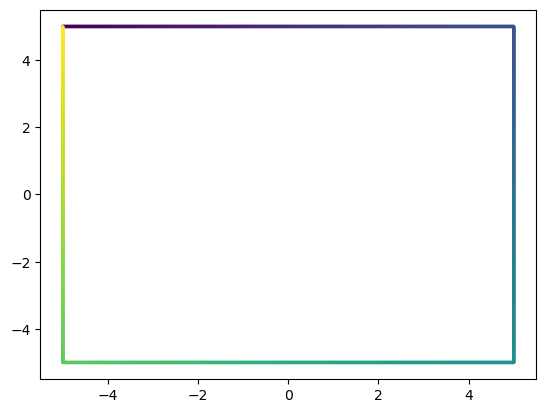

In [15]:
nsegment = 1000

segment = np.linspace(-lh, lh, nsegment+1)
fixed_segment = np.ones_like(segment)*lh

xs = np.concatenate([segment[:-1], fixed_segment[:-1], segment[:0:-1], -fixed_segment[:-1]])
ys = np.concatenate([fixed_segment[:-1], -segment[:-1], -fixed_segment[:-1], segment[:-1]])

plt.scatter(xs, ys, c=np.arange(len(xs)),s=2);

np.float64(3.396939045058156e-11)

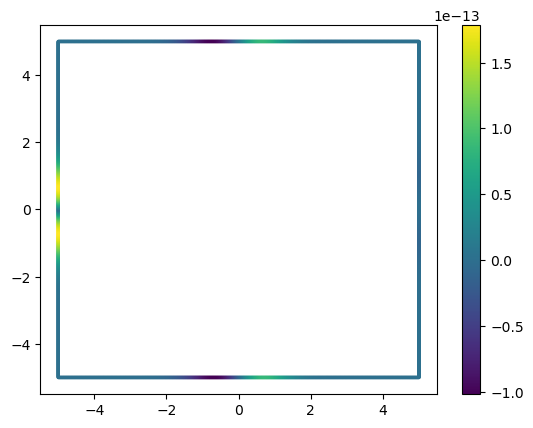

In [16]:
vals = line_integrand(xs, ys, n)
plt.scatter(xs, ys, c=vals, s=2)
plt.colorbar()
np.sum(vals)

Wha huh?? Why would it be *zero*?? Could there be some divergence in the partial derivative I'm missing?

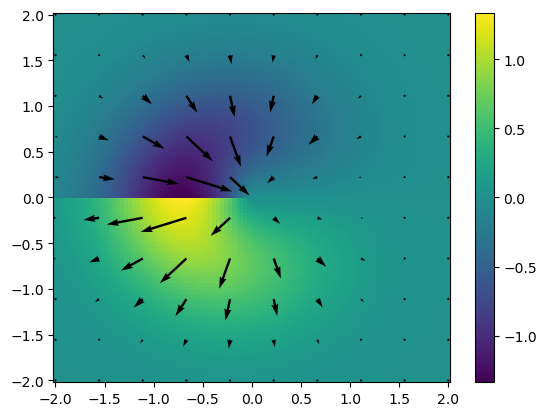

In [17]:
y,x=np.mgrid[-2:2:100j,-2:2:100j]
r=np.hypot(x,y)
phi=np.atan2(y,x)

n = 0.5

f = -r*phi*np.exp(-r**(1/n))

plt.pcolor(x,y,f) 
plt.colorbar()


xf = np.cos(phi)*f
yf = np.sin(phi)*f

qmsk = (slice(None, None, 11), slice(None, None, 11))
plt.quiver(x[qmsk],y[qmsk],xf[qmsk],yf[qmsk], angles='xy', scale=10)

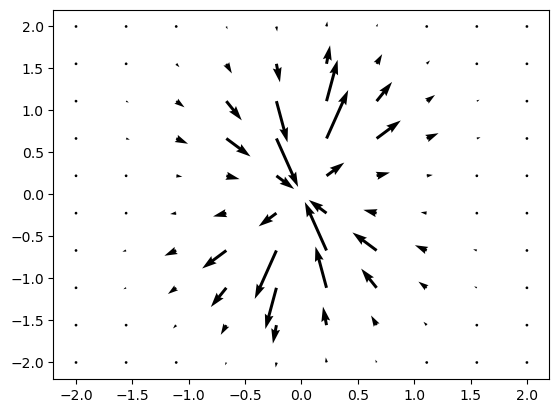

In [18]:
xf = fFx(x,y,n)
yf = fFy(x,y,n)
plt.quiver(x[qmsk],y[qmsk],xf[qmsk],yf[qmsk], angles='xy', scale=5)

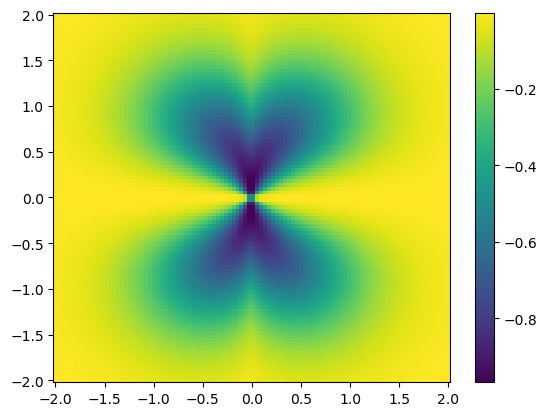

In [19]:
plt.pcolor(x,y,fdFydx(x,y,n)) 
plt.colorbar()

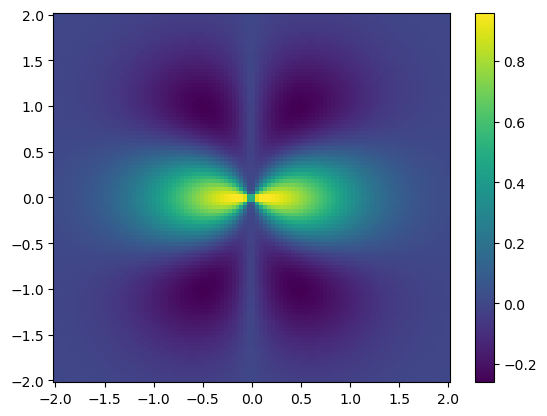

In [20]:
plt.pcolor(x,y,fdFxdy(x,y,n)) 
plt.colorbar()

partial deriavatives look continuous...

Check some assumptions by doing a more analytically straightforward example.

# Simpler problem

Let the area integral be $I \equiv \iint r^2 dA$ where dA is a circle of radius R = $\int_0^{2 \pi} \int_0^R  r^3 dr d\theta = 2\pi \int_0^R  r^3 dr = \frac{\pi}{2} R^4 $

Greens theorem says

$\iint \frac{\partial A_y}{\partial x} - \frac{\partial A_x}{\partial y} dA = \oint A_x dx + A_y dy$

which means 

$ \frac{\partial A_y}{\partial x} - \frac{\partial A_x}{\partial y} = r^2 = x^2 + y^2$

which suggests:

$ A_x = -\frac{y^3}{3}$

$ A_y = \frac{x^3}{3}$

thus the contour integral is:

$I = \frac{1}{3} \oint -y^3 dx + x^3 dy$

now assume a circular path:

$x = R \cos(t) \implies dx = -R \sin(t) dt$

$y = R \sin(t) \implies dy = R \cos(t) dt$

$I = \frac{1}{3} \int_0^{2 \pi} -(R \sin(t))^3 (-R \sin(t)) dt + (R \cos(t))^3 R \cos(t) dt$

$ = \frac{R^4}{3} \int_0^{2 \pi} (\sin(t)^4  +  \cos(t)^4) dt $

In [21]:
t = sympy.symbols('t', real=True)
sympy.integrate(sympy.sin(t)**4 + sympy.cos(t)**4, (t, 0, 2*sympy.pi))

3*pi/2

$ = \frac{R^4}{3} \frac{3 \pi}{2} = \frac{\pi}{2} R^4  $

So the whole story fits.  Now lets try doing it numerically as above.

In [22]:
R = 1.5

def simpler_integrand(y, x):
    r = np.hypot(x, y)
    return r**2

i = integrate.dblquad(simpler_integrand, 
                      -R, R, 
                      lambda x:-np.sqrt(R**2 - x**2), 
                      lambda x: np.sqrt(R**2 - x**2)), 
i, (np.pi/2)*R**4

(((7.952156404398541, 6.320439016604951e-08),), 7.9521564043991635)

In [23]:
R = 1.5

N = 1000

def simpler_line_integrand(x, y):
    Ax = -y**3/3
    Ay = x**3/3
    
    dx = np.diff(np.insert(x, -1, x[0]))
    dy = np.diff(np.insert(y, -1, y[0]))

    return Ax*dx + Ay*dy

t = np.linspace(-np.pi, np.pi, N)
x = R*np.cos(t)
y = R*np.sin(t)

i = simpler_line_integrand(x, y)
np.sum(i), (np.pi/2)*R**4

(np.float64(7.9521039766075985), 7.9521564043991635)

So this procedure works.  Notably, though, it gave 0 again if the minus sign is left off of Ax.  Maybe there's a minus sign error above?

## Same problem, but using polar coordinates

Polar version of green's theorem via stokes theorem in 2D:

$\iint (\nabla \times \vec{F}) \cdot \hat{n} dA = \oint \vec{F} \cdot d\vec{l}$

$\hat{n} = \hat{z}$ and assume cylindrical coordinates:

$\iint dA \frac{1}{r} \frac{\partial (rF_\phi)}{\partial r} - \frac{1}{r} \frac{\partial F_r}{\partial \phi} = \oint \vec{F} \cdot d\vec{l}$

which means 

$\frac{1}{r} \frac{\partial (rF_\phi)}{\partial r} - \frac{1}{r} \frac{\partial F_r}{\partial \phi} = r^2$

A possible choice is

$ F_\phi = 0 , F_r = - \phi r^3$

which gives a polar boundary integral:

$\oint  \phi r^3 dr$

... which cannot be calculated on a circular path because $dr=0$? So then what if we convert to cartesian:

$\oint  \arctan(\frac{y}{x}) (x^2 + y^2)^\frac{3}{2} dr$

$= \oint  \arctan(\frac{y}{x}) (x^2 + y^2)^\frac{3}{2} (\frac{1}{2} (x^2 + y^2)^{-\frac{1}{2}}(2 x dx + 2 y dy) $

$= \oint 2 \arctan(\frac{y}{x}) (x^2 + y^2)(x dx + y dy) $

In [24]:
R = 1.5

N = 1000

def polar_simpler_line_integrand(x, y):
    shared = 2*np.arctan2(y,x)*(x*x+y*y)
    Ax = shared*x
    Ay = shared*y
    
    dx = np.diff(np.insert(x, -1, x[0]))
    dy = np.diff(np.insert(y, -1, y[0]))

    return Ax*dx + Ay*dy

t = np.linspace(-np.pi, np.pi, N)
x = R*np.cos(t)
y = R*np.sin(t)

i = polar_simpler_line_integrand(x, y)
np.sum(i), (np.pi/2)*R**4

(np.float64(0.0006291326692141608), 7.9521564043991635)

Ok... there's clearly an issue there.  Lets consider the divergence theorem version in spherical coordinates:

$\iint (\nabla \cdot \vec{F}) dA = \oint \vec{F} \cdot \hat{n} dl$ where $\hat{n}$ is the *normal* to the boundary.

LHS: $\iint (\nabla \cdot \vec{F}) dA \implies \nabla \cdot \vec{F} = r^2 \implies \frac{1}{r} \frac{\partial (r F_r)}{\partial r} + \frac{1}{r} \frac{\partial F_\phi}{\partial \phi} = r^2$

For circle radius R, $\oint \vec{F} \cdot \hat{n} dl = \oint F_r dr$ 

Option 1: $F_r=0, F_\phi=\phi r^3$

Option 2: $F_r=\frac{r^3}{4}, F_\phi=0$

MISTAKE REALIZED: the line element for the RHS is still a vector quantity, you can't drop the non-radial components!:

$\oint_C \vec{F} \cdot \hat{n} dl =  \int_C F \cdot \hat{n} dr + \int_C r F \cdot \hat{n} d\phi + \int_C F \cdot \hat{n} dz$ 

so for a circle radius R in the z plane, $dz$ and $dr$ are zero, but $d\phi$ is not so:   $= \int_C r F \cdot \hat{n} d\phi = \int_0^{2\pi} R F(r=R,z=0) \cdot \hat{n} d\phi = \int_0^{2\pi} R F_r(r=R, z=0) d\phi $.  That means the options give:

Option 1: $\int_0^{2\pi} R  0 d\phi = 0$

Option 2: $\int_0^{2\pi} \frac{R^4}{4} d\phi  = \frac{\pi}{2} R^4$

So option 1 is still problematic, but at least option 2 makes sense. This is perhaps because $\phi$ has a discontinuity?

# Trying various functions with sympy+

In [26]:
r,α = sympy.symbols('r,α', real=True, positive=True)
ϕ,x,y = sympy.symbols('ϕ,x,y', real=True)

In [27]:
R = 1.5 # the radius of the circular path
αval = 2 # a possible parameter

In [28]:
Fx = Fy = Fr = Fϕ = None

Fr = r-r
Fϕ = sympy.integrate(r*sympy.exp(-r**α), r)/r

#option 1
# Fr = r-r
# Fϕ = ϕ*r**3 

# option 2
# Fr = r**3/4
# Fϕ = r-r 


In [29]:
if Fr is None and Fϕ is None:
    Fr = (Fx * sympy.cos(ϕ) + Fy * sympy.sin(ϕ))
    Fϕ = (Fx * -sympy.sin(ϕ) + Fy * sympy.cos(ϕ))
elif Fx is None and Fy is None:
    Fx = Fr*x/r - Fϕ*y/r
    Fy = Fr*y/r + Fϕ*x/r
else:
    assert False, 'Need to set one of the pairs to None'


# allows mixing all variables above
Fr = Fr.subs({x:r*sympy.cos(ϕ), y:r*sympy.sin(ϕ)})
Fϕ = Fϕ.subs({x:r*sympy.cos(ϕ), y:r*sympy.sin(ϕ)})

Fx = Fx.subs({r:sympy.sqrt(x*x+y*y), ϕ:sympy.atan2(y,x)})
Fy = Fy.subs({r:sympy.sqrt(x*x+y*y), ϕ:sympy.atan2(y,x)})

The potential function

In [30]:
Fx.simplify()

-y*lowergamma(2/α, (x**2 + y**2)**(α/2))/(α*(x**2 + y**2))

In [31]:
Fy.simplify()

x*lowergamma(2/α, (x**2 + y**2)**(α/2))/(α*(x**2 + y**2))

In [32]:
Fr.simplify()

0

In [33]:
Fϕ.simplify()

lowergamma(2/α, r**α)/(r*α)

<lambdifygenerated-5>:2: RuntimeWarning: invalid value encountered in divide
  return -1/2*y*(1 - exp(-x**2 - y**2))/(x**2 + y**2)
<lambdifygenerated-6>:2: RuntimeWarning: invalid value encountered in divide
  return (1/2)*x*(1 - exp(-x**2 - y**2))/(x**2 + y**2)


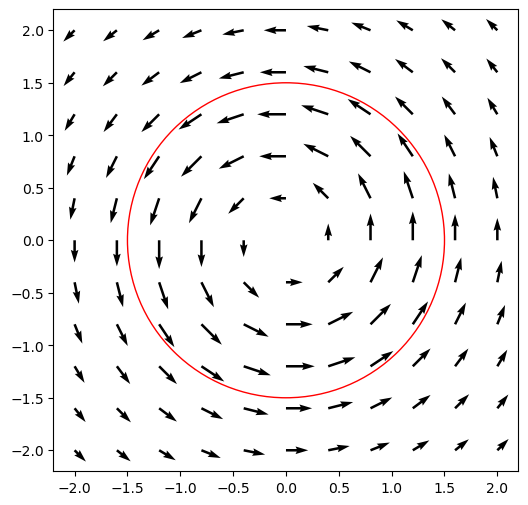

In [34]:
fx = sympy.lambdify((x,y), Fx.subs({α: αval}), 'numpy')
fy = sympy.lambdify((x,y), Fy.subs({α: αval}), 'numpy')

xgrid, ygrid = np.mgrid[-2:2:11j, -2:2:11j]

plt.figure(figsize=(6,6))
plt.quiver(xgrid, ygrid, fx(xgrid,ygrid), fy(xgrid,ygrid))
plt.gca().add_patch(plt.Circle((0, 0), R, fc='none', ec='red'));

The things that could be the area integrand

In [35]:
divc = sympy.diff(Fx, x) + sympy.diff(Fy, y)
divc.simplify()

0

In [36]:
curlc = sympy.diff(Fy, x) - sympy.diff(Fx, y)
curlc.simplify()

exp(-(x**2 + y**2)**(α/2))

In [37]:
divp = (sympy.diff(r*Fr, r)  + sympy.diff(Fϕ, ϕ))/r
divp.simplify()

0

In [38]:
curlp = (sympy.diff(r*Fϕ, r)  - sympy.diff(Fr, ϕ))/r
curlp.simplify()

exp(-r**α)

Plots and integrals

((0.0, 0), np.float64(0.0))

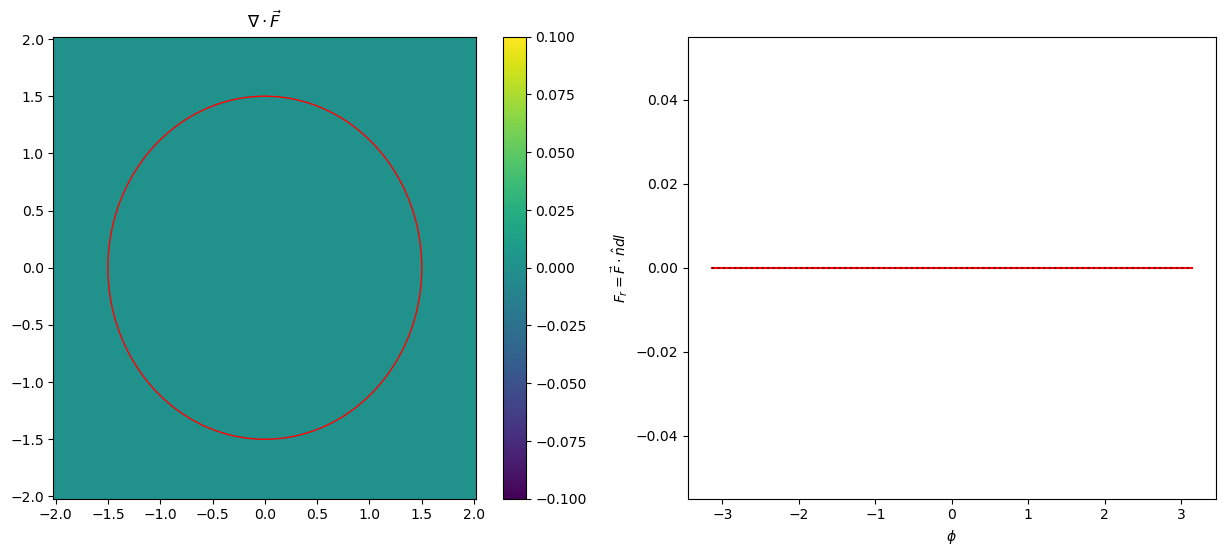

In [39]:
xgrid, ygrid = np.mgrid[-2:2:100j, -2:2:100j]

fdiv = sympy.lambdify((x,y), divc.subs({α: αval}), 'numpy')
fcurl = sympy.lambdify((x,y), curlc.subs({α: αval}), 'numpy')

fr = sympy.lambdify((r, ϕ), Fr.subs({α: αval}), 'numpy')
fϕ = sympy.lambdify((r, ϕ), Fϕ.subs({α: αval}), 'numpy')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))

c1 = ax1.pcolor(xgrid, ygrid, fdiv(xgrid, ygrid)*np.ones_like(xgrid))
plt.colorbar(c1, ax=ax1)
ax1.set_title(r'$\nabla \cdot \vec{F}$')
ax1.add_patch(plt.Circle((0, 0), R, fc='none', ec='red'))

t = np.linspace(-np.pi, np.pi, N)
ax2.plot(t, R*fr(R, t)*np.ones_like(t), c='r')
ax2.plot(t, t*0, ls=':', c='k', alpha=.5)
ax2.set_xlabel(r'$\phi$')
ax2.set_ylabel(r'$F_r = \vec{F} \cdot \hat{n} dl$')

idiv = integrate.dblquad(sympy.lambdify((ϕ, r), r*divp.subs({α: αval}), 'numpy'), 
                      0, R, 
                      lambda x:0, 
                      lambda x: 2*np.pi)

dt = np.diff(np.insert(t,-1, t[0]))
iperp = np.sum(R*fr(R, t)*np.ones_like(t)*dt)

idiv, iperp

((2.8104712240121787, 3.1202498629447667e-14), np.float64(2.810471224012179))

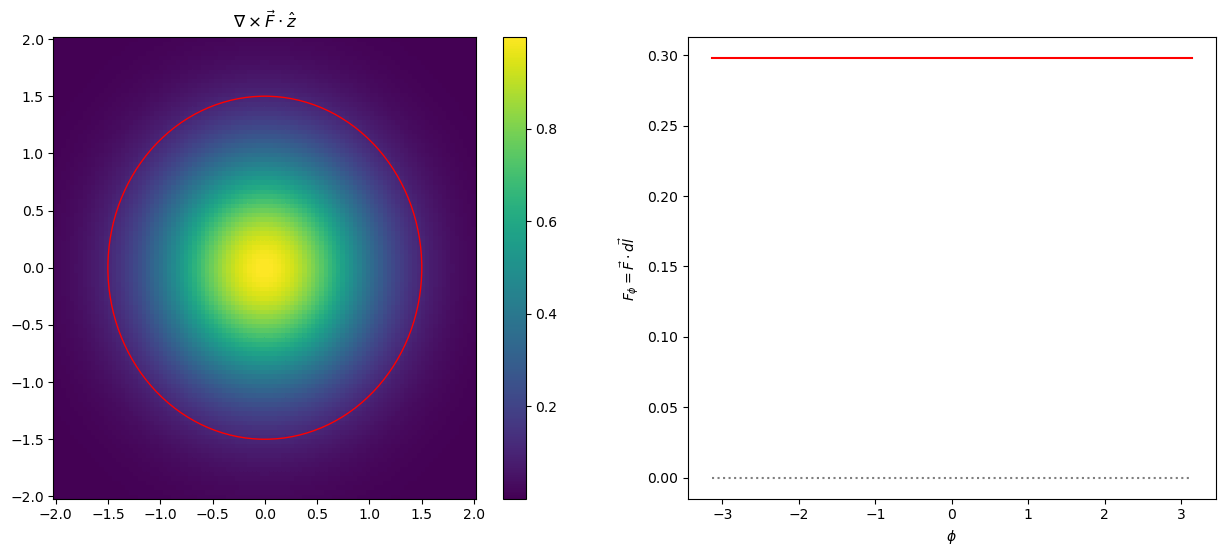

In [40]:
xgrid, ygrid = np.mgrid[-2:2:100j, -2:2:100j]

fdiv = sympy.lambdify((x,y), divc.subs({α: αval}), 'numpy')
fcurl = sympy.lambdify((x,y), curlc.subs({α: αval}), 'numpy')

fr = sympy.lambdify((r, ϕ), Fr.subs({α: αval}), 'numpy')
fϕ = sympy.lambdify((r, ϕ), Fϕ.subs({α: αval}), 'numpy')
fϕtr = sympy.lambdify((r, ϕ), Fϕ.subs({α: αval})*r, 'numpy')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))

c2 = ax1.pcolor(xgrid, ygrid, fcurl(xgrid, ygrid)*np.ones_like(xgrid))
plt.colorbar(c2, ax=ax1)
ax1.set_title(r'$\nabla \times \vec{F} \cdot \hat{z}$')
ax1.add_patch(plt.Circle((0, 0), R, fc='none', ec='red'))

t = np.linspace(-np.pi, np.pi, N)
ax2.plot(t, fϕ(R, t)*np.ones_like(t), c='r')
ax2.plot(t, t*0, ls=':', c='k', alpha=.5)
ax2.set_xlabel(r'$\phi$')
ax2.set_ylabel(r'$F_\phi = \vec{F} \cdot d\vec{l}$')

icurl = integrate.dblquad(sympy.lambdify((r, ϕ), r*curlp.subs({α: αval}), 'numpy'), 
                          -np.pi, np.pi, 
                          lambda x: 0, 
                          lambda x: R)
iline = np.sum(fϕtr(R, t)*np.ones_like(t)*dt)

icurl, iline

# Correct answer for sersic integral

From the above guess-and-check, got that this will give the integral of the normalized sersic function where $\alpha \equiv 1/n$

In [41]:
Fr = r-r
Fϕ = sympy.integrate(r*sympy.exp(-r**α), r)/r

Fϕ.simplify()

lowergamma(2/α, r**α)/(r*α)

In [42]:
Fx = (Fr*x/r - Fϕ*y/r).subs({r:sympy.sqrt(x*x+y*y), ϕ:sympy.atan2(y,x)})
Fy = (Fr*y/r + Fϕ*x/r).subs({r:sympy.sqrt(x*x+y*y), ϕ:sympy.atan2(y,x)})

In [43]:
Fx.simplify()

-y*lowergamma(2/α, (x**2 + y**2)**(α/2))/(α*(x**2 + y**2))

In [44]:
Fy.simplify()

x*lowergamma(2/α, (x**2 + y**2)**(α/2))/(α*(x**2 + y**2))

In [45]:
n = sympy.symbols('n', real=True, positive=True)

cartsoln = (Fx*dx + Fy*dy).subs({α:1/n}).simplify()
cartsoln

n*(-dx*y + dy*x)*lowergamma(2*n, (x**2 + y**2)**(1/(2*n)))/(x**2 + y**2)

That's not that crazy of a solution, could be numerically done fairly straightforwardly, using this:

In [46]:
SciPyPrinter().doprint(cartsoln)

'n*(-dx*y + dy*x)*scipy.special.gamma(2*n)*scipy.special.gammainc(2*n, (x**2 + y**2)**((1/2)/n))/(x**2 + y**2)'

But lets just see, if we parametrize a line on $t \in [0,1]$, and see if we can get any sort of convenient analytic solution:

$
\begin{align}
x & = t (x_2-x_1) + x_1 \\
y & = t (y_2-y_1) + y_1 \\
\\
dx & = (x_2-x_1) dt \\
dy & = (y_2-y_1) dt
\end{align}
$

In [47]:
t,x1,x2,y1,y2 = sympy.symbols('t,x_1,x_2,y_1,y_2', real=True)

Fx.subs({x: t*(x2 - x1) + x1, y: t*(y2 - y1) + y1}).simplify()

2*(t*(y_1 - y_2) - y_1)*gamma(2/α)*lowergamma(2/α, ((t*(x_1 - x_2) - x_1)**2 + (t*(y_1 - y_2) - y_1)**2)**(α/2))/(α**2*((t*(x_1 - x_2) - x_1)**2 + (t*(y_1 - y_2) - y_1)**2)*gamma(1 + 2/α))

In [48]:
reparam = (Fx.subs({x: t*(x2 - x1) + x1, y: t*(y2 - y1) + y1})*dx + Fy.subs({x: t*(x2 - x1) + x1, y: t*(y2 - y1) + y1})*dy).simplify()
reparam

(dx*t*y_1 - dx*t*y_2 - dx*y_1 - dy*t*x_1 + dy*t*x_2 + dy*x_1)*lowergamma(2/α, (t**2*x_1**2 - 2*t**2*x_1*x_2 + t**2*x_2**2 + t**2*y_1**2 - 2*t**2*y_1*y_2 + t**2*y_2**2 - 2*t*x_1**2 + 2*t*x_1*x_2 - 2*t*y_1**2 + 2*t*y_1*y_2 + x_1**2 + y_1**2)**(α/2))/(α*(t**2*x_1**2 - 2*t**2*x_1*x_2 + t**2*x_2**2 + t**2*y_1**2 - 2*t**2*y_1*y_2 + t**2*y_2**2 - 2*t*x_1**2 + 2*t*x_1*x_2 - 2*t*y_1**2 + 2*t*y_1*y_2 + x_1**2 + y_1**2))

Unsurprisingly the above is hideous and doesn't seem to integrate to anything useful, so a numerical approach is probably better, although the above parameterization probably will make it more stable.